# Calibrate Pretraining

I expect pretraining the preference ranking MLP on naturalness should do _something_ but currently (4/20/25) seeing no difference at all. Let's do some debugging / tuning (epochs, learning rate, batch size, etc).

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns

# Configure logging
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

from folde.data import get_available_proteingym_datasets, get_proteingym_dataset
from folde.campaign import simulate_campaign, simulate_campaigns
from folde.types import FolDEModelConfig, ModelEvaluation

In [2]:
available_datasets = get_available_proteingym_datasets('300m_extras', '600m')
assert not available_datasets.empty
available_datasets.head(10)

2025-04-25 15:42:14,473 - folde.data - INFO - Loaded metadata for 217 DMS datasets
2025-04-25 15:42:14,823 - folde.data - INFO - Found 9 datasets with embedding model '300m_extras' and naturalness model '600m'


,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
15,ANCSZ_Hobbs_2022,ANCSZ_Hobbs_2022.csv,ANCSZ,Eukaryote,Reconstructed ancestor,MADSANHLPYFYGSITREEAEDYLKQGGMSDGLFLLRQSLNSLGGY...,627,False,4670,4670,...,ANCSZ_Hobbs_2022.csv,DMS_value,1,mutant,ANCSZ_theta_0.2.npy,ANCSZ.pdb,1-627,1.0,NaN,Activity
21,BLAT_ECOLX_Firnberg_2014,BLAT_ECOLX_Firnberg_2014.csv,BLAT_ECOLX,Prokaryote,Escherichia coli,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,286,False,4783,4783,...,BLAT_ECOLX_Firnberg_2014.csv,linear,1,mutant,BLAT_ECOLX_theta_0.2.npy,BLAT_ECOLX.pdb,1-286,0.1,NaN,OrganismalFitness
36,CBS_HUMAN_Sun_2020,CBS_HUMAN_Sun_2020.csv,CBS_HUMAN,Human,Homo sapiens,MPSETPQAEVGPTGCPHRSGPHSAKGSLEKGSPEDKEAKEPLWIRP...,551,False,7217,7217,...,NaN,score,1,mutant,CBS_HUMAN_theta0.2_2023-10-12_b08.npy,CBS_HUMAN.pdb,1-551,1.0,NaN,OrganismalFitness
72,HEM3_HUMAN_Loggerenberg_2023,HEM3_HUMAN_Loggerenberg_2023.csv,HEM3_HUMAN,Human,Homo sapiens,MSGNGNAAATAEENSPKMRVIRVGTRKSQLARIQTDSVVATLKASY...,361,False,5689,5689,...,NaN,score,1,mutant,HEM3_HUMAN_theta0.2_2023-08-07_b02.npy,HEM3_HUMAN.pdb,1-361,1.0,NaN,Activity
76,HSP82_YEAST_Flynn_2019,HSP82_YEAST_Flynn_2019.csv,HSP82_YEAST,Eukaryote,Saccharomyces cerevisiae,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,709,False,13294,13294,...,HSP82_YEAST_Flynn_2019.csv,s (37°C),1,mutant,HSP82_YEAST_theta_0.2.npy,HSP82_YEAST.pdb,1-709,1.0,NaN,OrganismalFitness
78,HXK4_HUMAN_Gersing_2022_activity,HXK4_HUMAN_Gersing_2022_activity.csv,HXK4_HUMAN,Human,Homo sapiens,MLDDRARMEAAKKEKVEQILAEFQLQEEDLKKVMRRMQKEMDRGLR...,465,False,8570,8570,...,HXK4_HUMAN_Gersing_2022.csv,score,1,mutant,HXK4_HUMAN_theta_0.2.npy,HXK4_HUMAN.pdb,1-465,1.0,NaN,OrganismalFitness
114,OXDA_RHOTO_Vanella_2023_activity,OXDA_RHOTO_Vanella_2023_activity.csv,OXDA_RHOTO,Eukaryote,Rhodotorula gracilis,HSQKRVVVLGSGVIGLSSALILARKGYSVHILARDLPEDVSSQTFA...,364,False,6396,6396,...,Figure_2.xlsx,activity fitness,1,mutant,OXDA_RHOTO_theta0.2_2023-08-07_b02.npy,OXDA_RHOTO.pdb,1-364,1.0,NaN,Activity
133,PPM1D_HUMAN_Miller_2022,PPM1D_HUMAN_Miller_2022.csv,PPM1D_HUMAN,Human,Homo sapiens,MAGLYSLGVSVFSDQGGRKYMEDVTQIVVEPEPTAEEKPSPRRSLS...,605,False,7889,7889,...,PPM1D_HUMAN_Miller_2022_raw.xlsx,fitness,1,mutant,PPM1D_HUMAN_theta0.2_2023-10-12_b01.npy,PPM1D_HUMAN.pdb,1-605,1.0,NaN,OrganismalFitness
178,SHOC2_HUMAN_Kwon_2022,SHOC2_HUMAN_Kwon_2022.csv,SHOC2_HUMAN,Human,Homo sapiens,MSSSLGKEKDSKEKDPKVPSAKEREKEAKASGGFGKESKEKEPKTK...,582,False,10972,10972,...,2022.3.16.Extended Data Table 4.csv,LFC_scaled,1,variant.by.aa,SHOC2_HUMAN_theta0.2_2023-10-12_b04.npy,SHOC2_HUMAN.pdb,1-582,1.0,NaN,OrganismalFitness


In [6]:
naturalness_df, embedding_df, activity_df = get_proteingym_dataset(
    'HSP82_YEAST_Flynn_2019',  # Chosen because naturalness has decent predictive power.
    '300m_extras',
    '600m',
)

2025-04-25 15:43:55,695 - folde.data - INFO - Loaded activity data for HSP82_YEAST_Flynn_2019 with 13294 rows
2025-04-25 15:44:45,066 - folde.data - INFO - Loaded embeddings for HSP82_YEAST_Flynn_2019 with 13472 rows
2025-04-25 15:44:45,287 - folde.data - INFO - Loaded naturalness scores for HSP82_YEAST_Flynn_2019 with 23397 rows


In [51]:
naturalness_df2, embedding_df2, activity_df2 = get_proteingym_dataset(
    'SHOC2_HUMAN_Kwon_2022',  # Chosen because naturalness has decent predictive power.
    '300m_extras',
    '600m',
)

2025-04-21 16:40:38,409 - folde.data - INFO - Loaded activity data for SHOC2_HUMAN_Kwon_2022 with 10972 rows
2025-04-21 16:40:56,802 - folde.data - INFO - Loaded embeddings for SHOC2_HUMAN_Kwon_2022 with 11059 rows
2025-04-21 16:40:56,859 - folde.data - INFO - Loaded naturalness scores for SHOC2_HUMAN_Kwon_2022 with 19206 rows


In [60]:
naturalness_df3, embedding_df3, activity_df3 = get_proteingym_dataset(
    'PPM1D_HUMAN_Miller_2022',  # Chosen because naturalness has decent predictive power.
    '300m_extras',
    '600m',
)

2025-04-21 16:43:18,366 - folde.data - INFO - Loaded activity data for PPM1D_HUMAN_Miller_2022 with 7889 rows
2025-04-21 16:43:31,301 - folde.data - INFO - Loaded embeddings for PPM1D_HUMAN_Miller_2022 with 11496 rows
2025-04-21 16:43:31,364 - folde.data - INFO - Loaded naturalness scores for PPM1D_HUMAN_Miller_2022 with 19965 rows


In [62]:
naturalness_df = naturalness_df.sort_values(by='wt_marginal')
naturalness_df['wtm_index'] = [v/float(len(naturalness_df)) for v in np.arange(len(naturalness_df))]
naturalness_df2 = naturalness_df2.sort_values(by='wt_marginal')
naturalness_df2['wtm_index'] = [v/float(len(naturalness_df2)) for v in np.arange(len(naturalness_df2))]
naturalness_df3 = naturalness_df3.sort_values(by='wt_marginal')
naturalness_df3['wtm_index'] = [v/float(len(naturalness_df3)) for v in np.arange(len(naturalness_df3))]


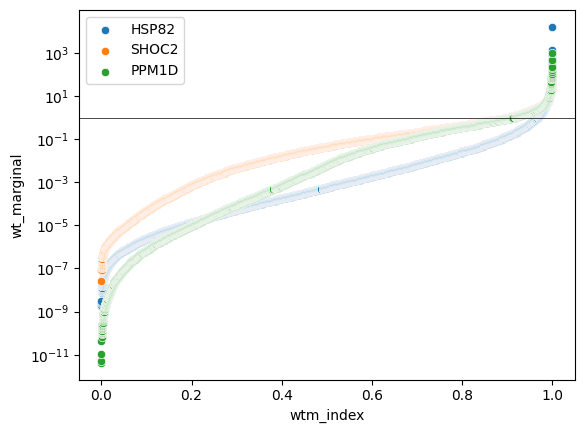

In [63]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.scatterplot(data=naturalness_df.sort_values(by='wt_marginal'), x='wtm_index', y='wt_marginal', label='HSP82')
sns.scatterplot(data=naturalness_df2.sort_values(by='wt_marginal'), x='wtm_index', y='wt_marginal', label='SHOC2')
sns.scatterplot(data=naturalness_df3.sort_values(by='wt_marginal'), x='wtm_index', y='wt_marginal', label='PPM1D')
plt.yscale('log')
plt.axhline(y=1.0, color='black', linewidth=0.5)

In [91]:
naturalness_df.sort_values('wt_marginal', ascending=False)

,seq_id,probability,locus,wt_probability,wt_marginal
seq_id,,,,,
L127A,L127A,8.828125e-01,127,0.000055,1.609906e+04
L127S,L127S,7.275391e-02,127,0.000055,1.326748e+03
R579V,R579V,6.757812e-01,579,0.000580,1.165474e+03
S411K,S411K,9.843750e-01,411,0.001152,8.544636e+02
Y305A,Y305A,7.734375e-01,305,0.001030,7.509333e+02
...,...,...,...,...,...
T101W,T101W,2.735760e-09,101,0.996094,2.746489e-09
L108D,L108D,2.459274e-09,108,0.957031,2.569690e-09
E149P,E149P,2.080924e-09,149,0.996094,2.089084e-09


In [93]:
import numpy as np
# Measure 16 activities.
all_seq_ids = activity_df.index.unique()
# measured_seq_ids = np.random.choice(all_seq_ids, size=16, replace=False)
measured_seq_ids = naturalness_df.sort_values('wt_marginal', ascending=False).iloc[:16].index
validation_seq_ids = np.random.choice([a for a in all_seq_ids if a not in measured_seq_ids], size=100, replace=False)

In [106]:
from folde.few_shot_models import TorchMLPFewShotModel

# Get few-shot model
pretrain_few_shot_model = TorchMLPFewShotModel(
    pretrain=True,
    pretrain_epochs=50,
    embedding_dim=960,
    hidden_dims=[100, 50],
    dropout=0.2,  # I don't know if this is important.
    learning_rate=1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
    weight_decay=1e-5,
    random_state=5,
)
nopretrain_few_shot_model = TorchMLPFewShotModel(
    pretrain=False,
    pretrain_epochs=50,
    embedding_dim=960,
    hidden_dims=[100, 50],
    dropout=0.2,  # I don't know if this is important.
    learning_rate=1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
    weight_decay=1e-5,
    random_state=5,
)

predicted_activity_series_list = []

for few_shot_model in [pretrain_few_shot_model, nopretrain_few_shot_model]:
    # Convert list of embeddings to numpy array
    entire_naturalness_series = naturalness_df.wt_marginal
    entire_embedding_series = embedding_df.embedding
    train_activity_series = activity_df.loc[measured_seq_ids].DMS_score
    validation_activity_series = activity_df.loc[validation_seq_ids].DMS_score

    few_shot_model.fit(
        entire_naturalness_series,
        entire_embedding_series,
        train_activity_series,
        validation_activity_series,
    )

    # Use the get_top_n method from FewShotModel
    top_seq_ids, predicted_activity_series = few_shot_model.get_top_n(
        16,
        entire_naturalness_series,
        entire_embedding_series,
    )
    predicted_activity_series_list.append(predicted_activity_series)

2025-04-25 23:36:42,706 - root - INFO - Pretraining model with naturalness data.
2025-04-25 23:39:52,528 - root - INFO - Pretrain improvement: train loss (0.3975 -> 0.2358) val loss (0.4106 -> 0.3478)
2025-04-25 23:39:52,817 - app.helpers.preference_ranking - INFO - Early stopping at epoch 10
2025-04-25 23:39:52,819 - root - INFO - Finetune improvement: train loss (2.1725 -> 0.2516) val loss (0.9619 -> 1.2342)
2025-04-25 23:39:55,384 - app.helpers.preference_ranking - INFO - Early stopping at epoch 10
2025-04-25 23:39:55,399 - root - INFO - Finetune improvement: train loss (0.7195 -> 0.2747) val loss (0.6931 -> 0.6932)


In [112]:
loss_df = pd.concat([
    pd.DataFrame({
        'model': 'no_pretrain',
        'loss': 'train',
        'value': nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss'],
        'epoch': range(len(nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss']))
    }),
    pd.DataFrame({
        'model': 'no_pretrain',
        'loss': 'val',
        'value': nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss'],
        'epoch': range(len(nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss']))
    }),
    pd.DataFrame({
        'model': 'pretrain',
        'loss': 'train',
        'value': (
            pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['train_loss'] + 
            pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss']
        ),
        'epoch': range(
            -len(pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['train_loss']),
            len(pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss'])
        )
    }),
    pd.DataFrame({
        'model': 'pretrain',
        'loss': 'val',
        'value': (
            pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['val_loss'] + 
            pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss']
        ),
        'epoch': range(
            -len(pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['val_loss']),
            len(pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss'])
        )
    })
], ignore_index=True)
loss_df['category'] = loss_df['model'] + '_' + loss_df['loss']

In [113]:
loss_df

,model,loss,value,epoch,category
0,no_pretrain,train,0.719530,0,no_pretrain_train
1,no_pretrain,train,0.507776,1,no_pretrain_train
2,no_pretrain,train,0.375397,2,no_pretrain_train
3,no_pretrain,train,0.371594,3,no_pretrain_train
4,no_pretrain,train,0.338445,4,no_pretrain_train
...,...,...,...,...,...
135,pretrain,val,NaN,5,pretrain_val
136,pretrain,val,NaN,6,pretrain_val
137,pretrain,val,NaN,7,pretrain_val
138,pretrain,val,NaN,8,pretrain_val


<Axes: xlabel='epoch', ylabel='value'>

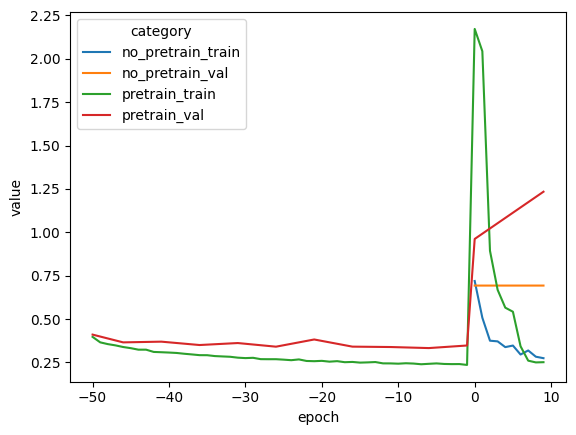

In [114]:
import seaborn as sns
sns.lineplot(data=loss_df, x='epoch', y='value', hue='category')

In [115]:
from scipy.stats import spearmanr

for lst in predicted_activity_series_list:
  print(spearmanr(lst[0], activity_df.DMS_score))


SignificanceResult(statistic=0.2704394346785104, pvalue=1.5539995575464568e-221)
SignificanceResult(statistic=-0.21561928837307243, pvalue=1.2483293719986463e-139)


<Axes: xlabel='None', ylabel='DMS_score'>

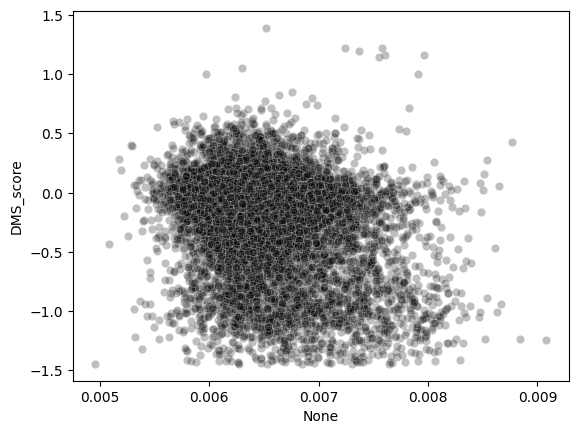

In [111]:
import seaborn as sns

sns.scatterplot(x=predicted_activity_series_list[1][0], y=activity_df.DMS_score, alpha=0.25, color='black')
# predicted_activity_series_list[0][0]

In [35]:
6782*2

13564

In [34]:
predicted_activity_series_list[0][0][predicted_activity_series_list[0][0].duplicated()]

seq_id
Y305A    1.614573
S602G    1.614573
Y289L    1.614573
K235Q    1.614573
E683W    1.614573
           ...   
F421V    1.614573
I524M    1.614573
G633D    1.614573
D534S    1.614573
I388A    1.614573
Length: 6782, dtype: float32